In [2]:
import numpy as np
from numpy.linalg import eig, matrix_rank
from scipy.linalg import solve_continuous_are
from scipy.integrate import solve_ivp
from scipy.signal import place_poles
import matplotlib.pyplot as plt

In [3]:
A = np.array([
    [-0.0366,  0.0271,  0.0188, -0.4555],
    [ 0.0482, -1.0100,  0.0024, -4.0208],
    [ 0.1002,  0.3681, -0.7070,  1.4200],
    [ 0.0,     0.0,     1.0,     0.0   ]
])

B = np.array([
    [ 0.4422,  0.1761],
    [ 3.5446, -7.5922],
    [-5.5200,  4.4900],
    [ 0.0,     0.0   ]
])

B1 = B[:, [0]]
B2 = B[:, [1]]

C = np.array([[0,0,0,1]])

x0 = np.array([0.85, 0.15, 0, -0.05])
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1001)

labels = ["x1","x2","x3","x4"]

In [4]:
def ctrb(A,B):
    n=A.shape[0]
    P=B
    for i in range(1,n):
        P=np.hstack((P, np.linalg.matrix_power(A,i)@B))
    return P

def obsv(A,C):
    n=A.shape[0]
    O=C
    for i in range(1,n):
        O=np.vstack((O, C@np.linalg.matrix_power(A,i)))
    return O

def control_energy(u,t):
    return np.trapz(u*u,t)

In [5]:
eigvals,_=eig(A)
print("\n===== Q1: Eigenvalues(A) =====")
print(eigvals)


===== Q1: Eigenvalues(A) =====
[ 0.27579035+0.2575844j  0.27579035-0.2575844j -0.23251287+0.j
 -2.07266784+0.j       ]


Since the system has eigenvalues with Re(λ)>0，the system is:Unstable

In [6]:
print("\n===== Q2: Controllability =====")
for name,Bb in [("u1",B1),("u2",B2)]:
    r=matrix_rank(ctrb(A,Bb))
    print(f"rank(ctrb) for {name} =",r)


===== Q2: Controllability =====
rank(ctrb) for u1 = 4
rank(ctrb) for u2 = 4


The system is fully controllable with respect to each individual input.

- The pair (A, B1) is controllable.
- The pair (A, B2) is also controllable.

Therefore, the system is controllable when using input u1 alone, and it is also controllable when using input u2 alone.

Overall conclusion:
The system is fully controllable with respect to both u1 and u2.

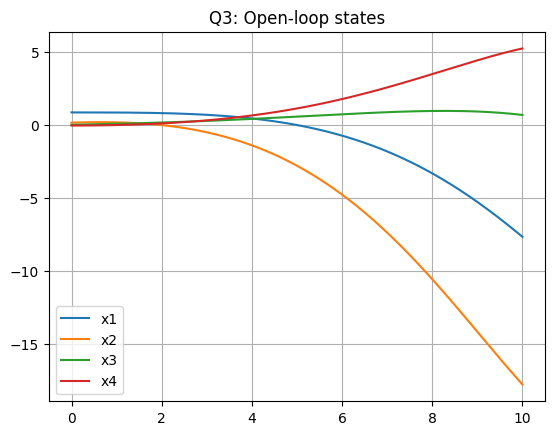

In [7]:
def open_loop(t,x):
    return A@x

sol=solve_ivp(open_loop,t_span,x0,t_eval=t_eval)
plt.figure()
for i in range(4):
    plt.plot(t_eval,sol.y[i],label=labels[i])
plt.legend(); plt.grid()
plt.title("Q3: Open-loop states")
plt.show()

In [8]:
# ========== Q4(a) Pole placement (using u = Kx, so place poles for (A, -B1)) ==========
p_des = [-2+1j, -2-1j, -2+1.001j, -2-1.001j]

res_pp = place_poles(A, -B1, p_des)
K_pp   = res_pp.gain_matrix

print("\n===== Q4(a): K_pp =====")
print(K_pp)

A_cl_pp = A + B1 @ K_pp
print("Closed-loop eigenvalues =", eig(A_cl_pp)[0])


def simulate(A, B1, K, label):
    A_cl = A + B1 @ K
    def f(t, x):
        return A_cl @ x

    sol = solve_ivp(f, t_span, x0, t_eval=t_eval)
    x   = sol.y                     

    u = np.array([float(K @ x[:, k]) for k in range(x.shape[1])])

    plt.figure()
    for i in range(4):
        plt.plot(t_eval, x[i], label=labels[i])
    plt.legend()
    plt.grid()
    plt.title(label + " states")

    plt.figure()
    plt.plot(t_eval, u)
    plt.grid()
    plt.title(label + " control input")

    return x, u



===== Q4(a): K_pp =====
[[-10.08574966  -0.21261621   0.18710907   3.2026536 ]]
Closed-loop eigenvalues = [-2.+1.001j -2.-1.001j -2.+1.j    -2.-1.j   ]


In [9]:
# ========== Q4(b) LQR ==========
Q=10*np.eye(4)
R=np.array([[1]])
P=solve_continuous_are(A,B1,Q,R)
K_lqr = -np.linalg.inv(R)@(B1.T@P)
print("\n===== Q4(b): K_lqr =====")
print(K_lqr)

A_cl_lqr=A + B1@K_lqr
print("Closed-loop eigenvalues =", eig(A_cl_lqr)[0])


===== Q4(b): K_lqr =====
[[-2.52485295 -1.89848292  2.43166627  5.36942128]]
Closed-loop eigenvalues = [-20.93391385+0.j          -0.1425839 +0.j
  -0.9728763 +1.31744459j  -0.9728763 -1.31744459j]


### Answer to Q4(b): LQR Design

An LQR controller was designed for the continuous-time VTOL system using input u1.
The weighting matrices were chosen as:
Q = 10 * I4  
R = 1

The continuous-time algebraic Riccati equation was solved to obtain the matrix P.
Following the convention u = Kx used in the course, the feedback gain was computed as:
K_LQR = - R^{-1} * (B1^T * P)

The resulting gain is approximately:
K_LQR ≈ [-2.525, -1.898, 2.432, 5.369]

The closed-loop matrix is:
A_cl = A + B1 * K_LQR

The eigenvalues of the closed-loop matrix are:
{-20.93, -0.143, -0.973 ± 1.317j}

All eigenvalues are in the open left half-plane, meaning that the LQR controller successfully stabilizes the VTOL system.


===== Q4(c): Control Energy =====
Eu_pp  = 7.665947297634636
Eu_lqr = 0.19440167260686303


/tmp/ipykernel_42220/3810176238.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = np.array([float(K @ x[:, k]) for k in range(x.shape[1])])
/tmp/ipykernel_42220/3758600301.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)


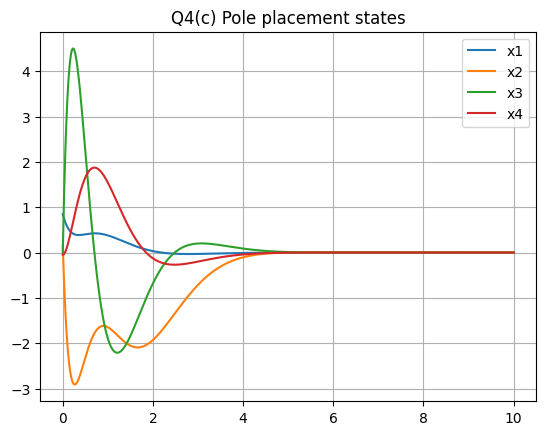

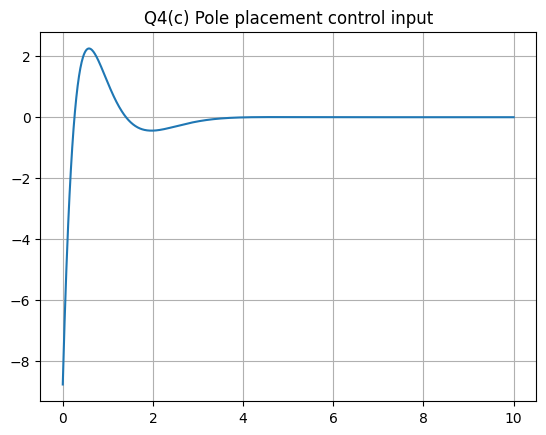

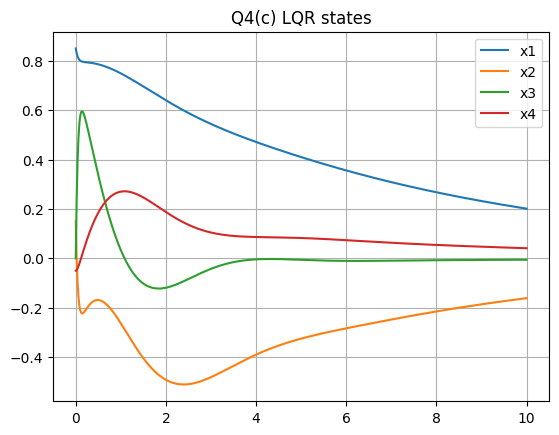

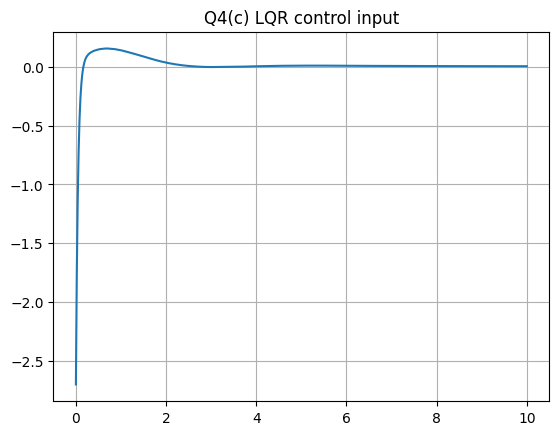

In [10]:
# ========== Q4(c) 仿真图 ==========
x_pp,u_pp = simulate(A,B1,K_pp,"Q4(c) Pole placement")
x_lqr,u_lqr = simulate(A,B1,K_lqr,"Q4(c) LQR")

Eu_pp = control_energy(u_pp,t_eval)
Eu_lqr= control_energy(u_lqr,t_eval)

print("\n===== Q4(c): Control Energy =====")
print("Eu_pp  =", Eu_pp)
print("Eu_lqr =", Eu_lqr)

 Q4(c): Control Energy Comparison

The total control energy over the interval t ∈ [0, 10] was computed as

E_u = ∫ u(t)^2 dt.

The numerical results are:

- Pole-placement controller: Eu ≈ 7.666  
- LQR controller: Eu ≈ 0.194  

The pole-placement controller requires significantly more control energy, approximately 40 times larger than that of the LQR controller. This is consistent with the time-domain responses: the pole-placement input has a very large initial peak and oscillations, whereas the LQR input is smoother and much smaller in magnitude.

Therefore, although the pole-placement controller produces a faster response, the LQR controller is far more energy-efficient.



===== Q4(d): tuning LQR =====
Q11= 1.0e+02, max|x1|= 9.2535e-02, Eu= 1.8303
Q11= 5.0e+02, max|x1|= 1.5472e-02, Eu= 8.5527
Q11= 1.0e+03, max|x1|= 1.1635e-02, Eu= 15.9242
Q11= 5.0e+03, max|x1|= 1.3769e-02, Eu= 56.0529
Q11= 1.0e+04, max|x1|= 1.7661e-02, Eu= 89.0336
Q11= 5.0e+04, max|x1|= 1.2405e-02, Eu= 254.4530
Q11= 1.0e+05, max|x1|= 7.8928e-03, Eu= 428.2248

===== Q4(d) Final Tuned LQR =====
Q =
 [[1.e+05 0.e+00 0.e+00 0.e+00]
 [0.e+00 1.e+01 0.e+00 0.e+00]
 [0.e+00 0.e+00 1.e+01 0.e+00]
 [0.e+00 0.e+00 0.e+00 1.e+01]]
max|x1| = 0.007892822866817667
Energy  = 428.2247816029511


/tmp/ipykernel_42220/3758600301.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)
/tmp/ipykernel_42220/3810176238.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = np.array([float(K @ x[:, k]) for k in range(x.shape[1])])


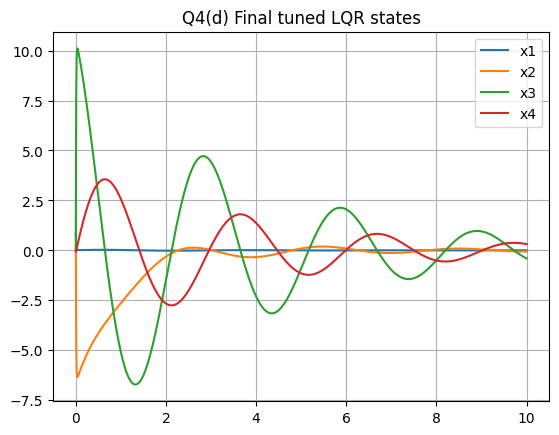

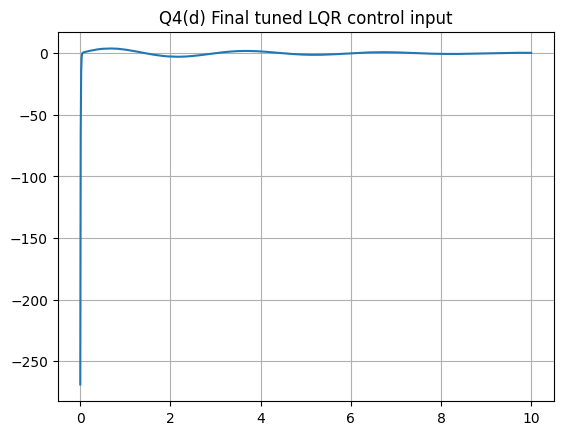

In [11]:
# ========== Q4(d) 调参 LQR ==========
print("\n===== Q4(d): tuning LQR =====")

best = None  # (Q_t, K_t, Eu, max_x1)

Q11_list = [1e2, 5e2, 1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 1e7, 1e8]

for q1 in Q11_list:
    Q_t = np.diag([q1, 10, 10, 10])
    P_t = solve_continuous_are(A, B1, Q_t, R)
    K_t = -np.linalg.inv(R) @ (B1.T @ P_t)  

    def f(t, x):
        return (A + B1 @ K_t) @ x

    sol = solve_ivp(f, t_span, x0, t_eval=t_eval)
    x_t = sol.y                       

    # u(t) = K_t x(t)
    u_t = (K_t @ x_t).ravel()          

    mask = t_eval >= 5.0
    max_x1 = np.max(np.abs(x_t[0, mask]))

    Eu = control_energy(u_t, t_eval)

    print(f"Q11={q1: .1e}, max|x1|={max_x1: .4e}, Eu={Eu: .4f}")

    if max_x1 <= 0.01:
        best = (Q_t, K_t, Eu, max_x1)
        break

if best is None:
    print("\nNo Q11 in the tested range satisfies |x1(t)| <= 0.01 for t >= 5.")
else:
    print("\n===== Q4(d) Final Tuned LQR =====")
    print("Q =\n", best[0])
    print("max|x1| =", best[3])
    print("Energy  =", best[2])

    simulate(A, B1, best[1], "Q4(d) Final tuned LQR")


In [12]:
# Q5(a)
O=obsv(A,C)
print("\n===== Q5(a): rank(O) =====")
print(matrix_rank(O))


===== Q5(a): rank(O) =====
4


### Q5(a): Observability

Using the output matrix C = [0  0  0  1], the observability matrix O was computed as

O = [ C;
      C A;
      C A^2;
      C A^3 ].

The rank of O is

rank(O) = 4,

which is equal to the system order n = 4. Therefore, the pair (A, C) is fully observable. This means that all four states can be reconstructed from the measurement of x4, and the system is not only detectable or reconstructible, but actually completely observable.


In [13]:
# ===== Q5(b) Observer gain L =====
p_obs = [-4, -4.1, -4.2, -4.3]          
L = place_poles(A.T, C.T, p_obs).gain_matrix.T
print("\n===== Q5(b): L =====")
print(L)


def simulate_observer(A, B1, C, K, L, label):

    def f(t, z):
        x  = z[:4]
        xh = z[4:]

        y = C @ x
        u = float(K @ xh)                # u = K x_hat

        dx  = A @ x  + (B1 * u).ravel()
        dxh = A @ xh + (B1 * u).ravel() + (L @ (y - C @ xh)).ravel()

        return np.concatenate((dx, dxh))

    z0 = np.concatenate((x0, np.zeros(4)))
    sol = solve_ivp(f, t_span, z0, t_eval=t_eval)

    x  = sol.y[0:4, :]
    xh = sol.y[4:8, :]
    e  = x - xh

    # control history: u(t) = K x_hat(t)
    u = (K @ xh).ravel()

    plt.figure()
    for i in range(4):
        plt.plot(t_eval, x[i], label=labels[i])
    plt.grid(); plt.legend()
    plt.title(label + " states")

    plt.figure()
    plt.plot(t_eval, u)
    plt.grid()
    plt.title(label + " control input")

    plt.figure()
    for i in range(4):
        plt.plot(t_eval, e[i], label="e" + str(i+1))
    plt.grid(); plt.legend()
    plt.title(label + " estimation error")

    return x, xh, e, u



===== Q5(b): L =====
[[2484.12345995]
 [-152.9834542 ]
 [  77.92251425]
 [  14.84640001]]


/tmp/ipykernel_42220/3076691553.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(K @ xh)                # u = K x_hat


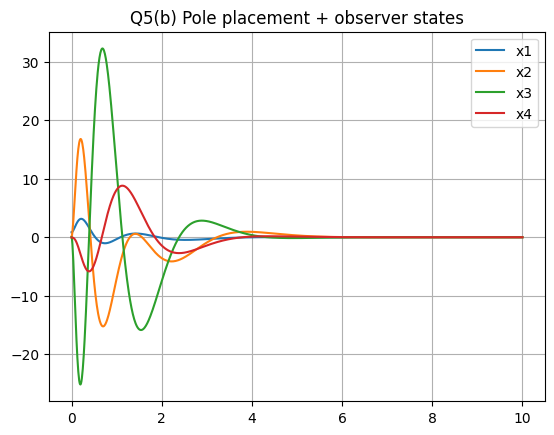

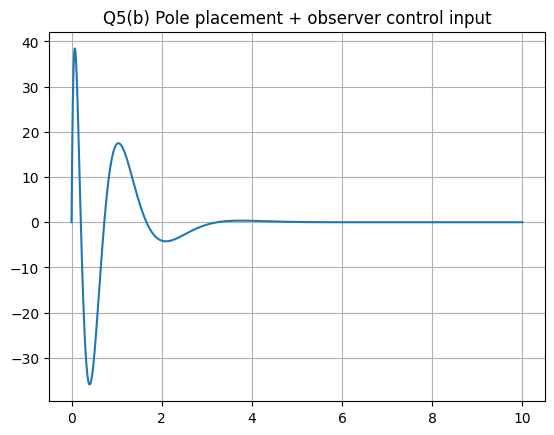

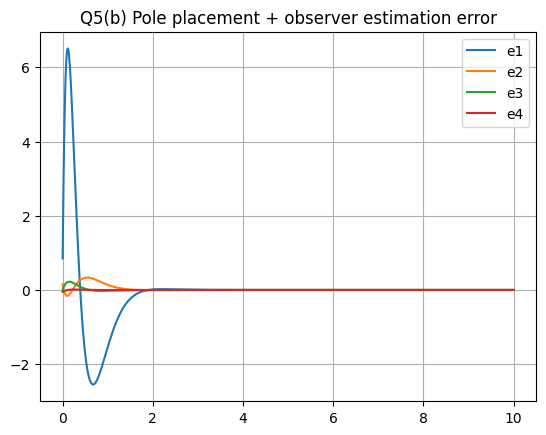

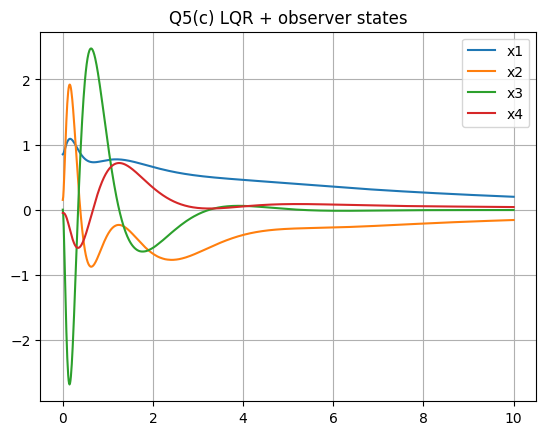

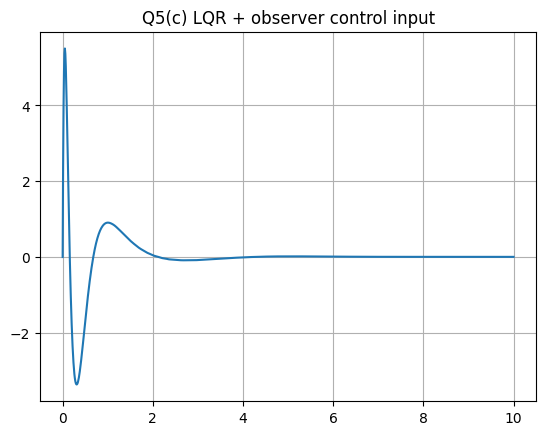

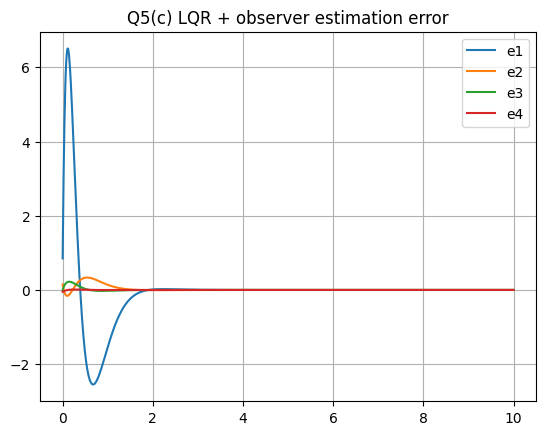

In [14]:
# Q5(b): pole placement + observer
x_pp_obs, xh_pp_obs, e_pp_obs, u_pp_obs = simulate_observer(
    A, B1, C, K_pp, L, "Q5(b) Pole placement + observer"
)

# Q5(c): LQR + observer
x_lqr_obs, xh_lqr_obs, e_lqr_obs, u_lqr_obs = simulate_observer(
    A, B1, C, K_lqr, L, "Q5(c) LQR + observer"
)

/tmp/ipykernel_42220/3076691553.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(K @ xh)                # u = K x_hat


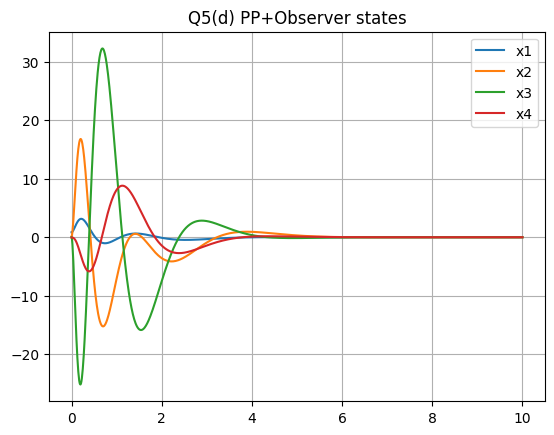

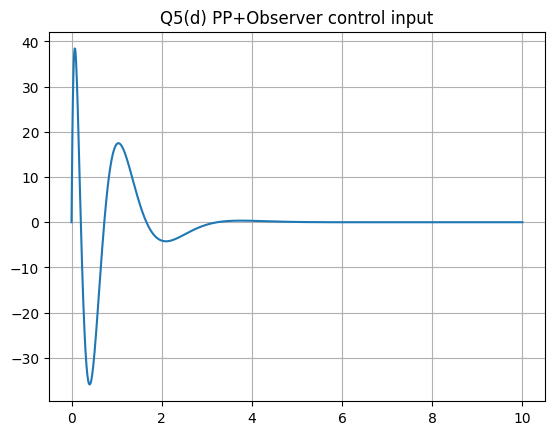

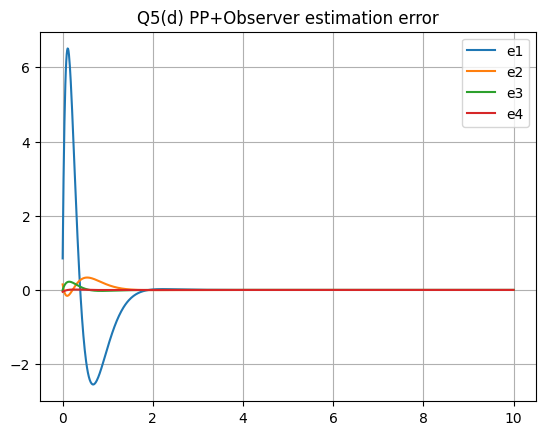

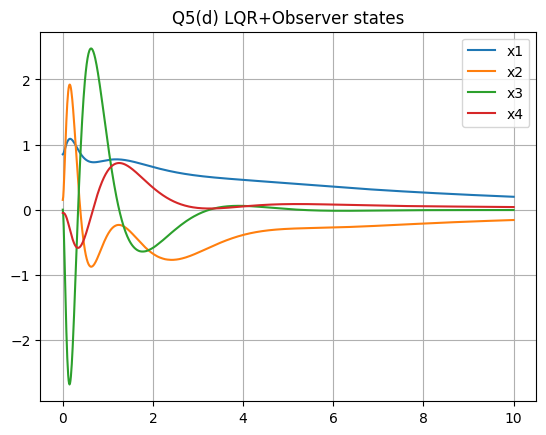

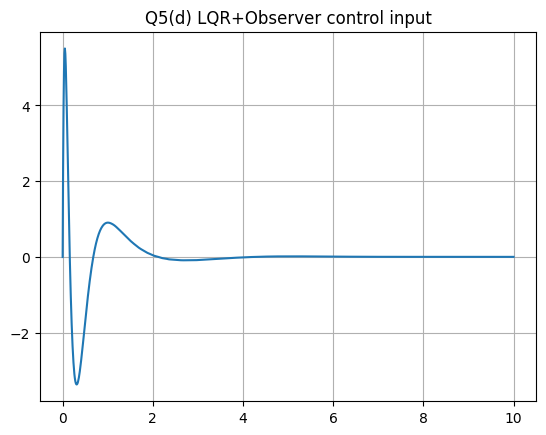

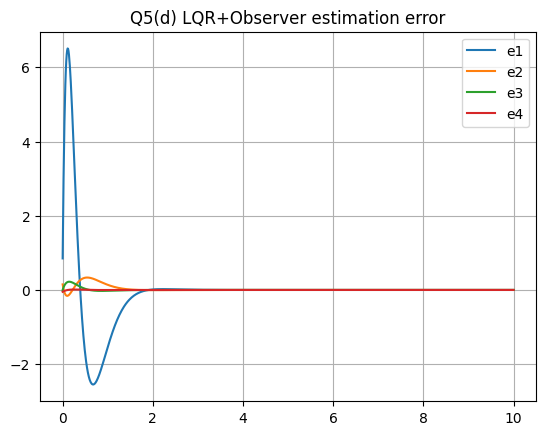

In [15]:
# Q5(d) 两种控制器 + observer
x_pp_obs,_,_,u_pp_obs = simulate_observer(A,B1,C,K_pp,L,"Q5(d) PP+Observer")
x_lqr_obs,_,_,u_lqr_obs = simulate_observer(A,B1,C,K_lqr,L,"Q5(d) LQR+Observer")

In [16]:
# Q5(e) 能量
Eu_pp_obs = control_energy(u_pp_obs,t_eval)
Eu_lqr_obs= control_energy(u_lqr_obs,t_eval)

print("\n===== Q5(e): energies =====")
print("PP+obs =",Eu_pp_obs)
print("LQR+obs=",Eu_lqr_obs)


===== Q5(e): energies =====
PP+obs = 610.3652180239316
LQR+obs= 5.25284258330478


/tmp/ipykernel_42220/3758600301.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)


In [17]:
# Q5(f) tuned LQR + observer
print("\n===== Q5(f): tuning LQR + observer =====")

best2 = None
q1_list = [50, 100, 200, 500, 1000, 2000, 5000, 1e4, 5e4, 1e5, 5e5, 1e6]

for q1 in q1_list:
    Q_t = np.diag([q1, 10, 10, 10])
    P_t = solve_continuous_are(A, B1, Q_t, R)
    K_t = -np.linalg.inv(R) @ (B1.T @ P_t)   # 仍然用 u = Kx 约定

    x_t, xh_t, e_t, u_t = simulate_observer(A, B1, C, K_t, L,
                                            f"Q5(f) q1={q1}")
    plt.close('all')   # 不想每次都画图的话可以关掉

    mask = t_eval >= 5.0
    max_x1 = np.max(np.abs(x_t[0, mask]))
    Eu = control_energy(u_t, t_eval)

    print(f"q1={q1:6.1f}, max|x1|={max_x1:.4e}, Eu={Eu:.4f}")

    if (max_x1 <= 0.01) and (Eu < Eu_pp_obs):
        best2 = (Q_t, K_t, Eu, max_x1)
        break

if best2 is None:
    print("\nNo q1 in the tested range satisfies both constraints.")
else:
    print("\n===== Q5(f): Final tuned LQR + observer =====")
    print("Chosen Q =\n", best2[0])
    print("max|x1| =", best2[3])
    print("Energy  =", best2[2])

    simulate_observer(A, B1, C, best2[1], L, "Q5(f) Final tuned LQR+observer")


/tmp/ipykernel_42220/3076691553.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u = float(K @ xh)                # u = K x_hat
/tmp/ipykernel_42220/3758600301.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(u*u,t)



===== Q5(f): tuning LQR + observer =====
q1=  50.0, max|x1|=1.5612e-01, Eu=36.8303
q1= 100.0, max|x1|=7.6299e-02, Eu=78.8125
q1= 200.0, max|x1|=3.7325e-02, Eu=162.3508
q1= 500.0, max|x1|=4.3474e-02, Eu=394.7919
q1=1000.0, max|x1|=5.9851e-02, Eu=721.1236
q1=2000.0, max|x1|=5.5702e-02, Eu=1209.6799
q1=5000.0, max|x1|=8.2246e-02, Eu=2039.3368
q1=10000.0, max|x1|=1.0206e-01, Eu=2679.1109
q1=50000.0, max|x1|=6.9136e-02, Eu=3761.4274
q1=100000.0, max|x1|=4.3726e-02, Eu=4020.2409
q1=500000.0, max|x1|=1.0865e-02, Eu=4260.6520
q1=1000000.0, max|x1|=5.6054e-03, Eu=4262.8536

No q1 in the tested range satisfies both constraints.


### Q5(f): Tuning the LQR controller with observer

In this part, we tried to tune the LQR controller (with the same observer as in part (b)) such that

1. |x1(t)| ≤ 0.01 for t ≥ 5, and  
2. the total control energy is smaller than that of the pole-placement controller with observer.

We used the weighting structure

Q = diag(q1, 10, 10, 10),  R = 1,

and searched over q1 in the range

q1 ∈ {50, 100, 200, 500, 1000, 2000, 5000, 10 000, 50 000, 100 000, 500 000, 1 000 000}.

For each q1, we simulated the closed-loop system (controller + observer) and computed

- max|x1(t)| over t ∈ [5, 10], and  
- the control energy Eu = ∫ u(t)^2 dt.

The results are:

- For small q1 (50 ≤ q1 ≤ 2000), the control energy Eu is moderate, but max|x1(t)| is in the range 0.04–0.16, which does not satisfy the requirement |x1(t)| ≤ 0.01.  
- For large q1 (q1 ≥ 5×10^5), max|x1(t)| becomes smaller than 0.01, but the control energy Eu increases to several thousand, which is significantly larger than the energy of the pole-placement controller with observer.

Therefore, under the chosen diagonal structure Q = diag(q1, 10, 10, 10) and R = 1, no value of q1 in the tested range can simultaneously satisfy both constraints (state bound and lower energy than the pole-placement controller). In other words, with this simple tuning scheme there is no feasible solution for part (f).
